[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flexfengfeng/dsai-m3-ml-genai/blob/main/L08-computer-vision/notebooks/01_monday_morning.ipynb)

# L08 · NB 01 — Monday morning: tagging product photos

> *Marcus's request, fresh out of Friday's stand-up: "Can we auto-tag product photos as dress, shirt, sneaker? We have ~10,000 new uploads each season."*

Sarah's first move is the simplest one she already knows: **flatten the images and train an MLP**. It's the same playbook she just used in L07. Does it work?

This notebook is pre-class. Run it before class so you walk in with an honest baseline number — and a sense of why we're going to need something better.

## 1 · Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torchvision.datasets import FashionMNIST
from torch.utils.data import DataLoader

torch.set_num_threads(1)
torch.manual_seed(42)
np.random.seed(42)

DEVICE = "cpu"
print("Torch:", torch.__version__, "| device:", DEVICE)

Torch: 2.12.0 | device: cpu


## 2 · Load Fashion-MNIST

Fashion-MNIST is a drop-in replacement for the classic MNIST digits — 70K 28×28 grayscale images of 10 apparel categories. Convenient stand-in for Marcus's catalogue.

In [2]:
transform = T.Compose([T.ToTensor()])  # converts to (C, H, W) float tensors in [0, 1]
DATA_ROOT = "data/fmnist"

train_ds = FashionMNIST(root=DATA_ROOT, train=True, download=True, transform=transform)
test_ds  = FashionMNIST(root=DATA_ROOT, train=False, download=True, transform=transform)

CLASSES = train_ds.classes
print(f"Train size : {len(train_ds):,}")
print(f"Test size  : {len(test_ds):,}")
print(f"Classes    : {CLASSES}")
print(f"Image shape: {train_ds[0][0].shape}  # (channels, height, width)")

Train size : 60,000
Test size  : 10,000
Classes    : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Image shape: torch.Size([1, 28, 28])  # (channels, height, width)


## 3 · Eyeball the data

Never model what you haven't looked at.

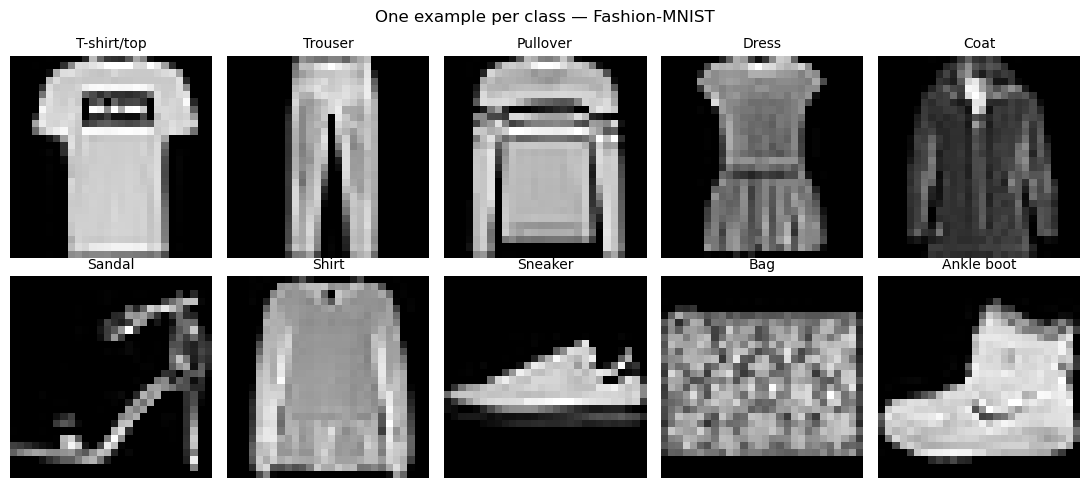

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for ax, cls_idx in zip(axes.flat, range(10)):
    # find one example of each class
    idx = next(i for i, (_, y) in enumerate(train_ds) if y == cls_idx)
    img, _ = train_ds[idx]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(CLASSES[cls_idx], fontsize=10)
    ax.axis('off')
plt.suptitle("One example per class — Fashion-MNIST", fontsize=12)
plt.tight_layout()
plt.show()

Stop and stare. Some of these are easy (sandals look very different from coats), but **shirt vs T-shirt/top vs pullover** is hard even for a human at thumbnail size. Keep that in mind when we evaluate accuracy in a minute.

## 4 · Flatten + MLP — the L07 playbook

Flatten each 28×28 image into a 784-dim vector. Then it's just tabular data, and we already know how to train an MLP on tabular data.

In [4]:
class FlatMLP(nn.Module):
    """Two-hidden-layer MLP on flattened pixels."""
    def __init__(self, in_dim=784, hidden=256, n_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),                  # (B, 1, 28, 28) -> (B, 784)
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, n_classes),
        )
    def forward(self, x):
        return self.net(x)

mlp = FlatMLP()
n_params = sum(p.numel() for p in mlp.parameters())
print(f"FlatMLP parameter count: {n_params:,}")
print(mlp)

FlatMLP parameter count: 235,146
FlatMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)


**~235K parameters** for tiny 28×28 images. Now imagine real product photos at 224×224 colour — the first layer alone would need 38 million weights. Tuck that away for later.

## 5 · Train the MLP

Standard L07 PyTorch training loop. We'll go 5 epochs — enough to get an honest number, fast enough to stay under a minute.

In [5]:
BATCH = 256
EPOCHS = 5
LR = 1e-3

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0)

optimizer = torch.optim.Adam(mlp.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / total

history = []
for epoch in range(1, EPOCHS + 1):
    mlp.train()
    running = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(mlp(xb), yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)
    train_loss = running / len(train_ds)
    test_acc = evaluate(mlp, test_loader)
    history.append((epoch, train_loss, test_acc))
    print(f"epoch {epoch} | train loss {train_loss:.4f} | test acc {test_acc:.4f}")

epoch 1 | train loss 0.6377 | test acc 0.8165


epoch 2 | train loss 0.4141 | test acc 0.8473


epoch 3 | train loss 0.3691 | test acc 0.8643


epoch 4 | train loss 0.3423 | test acc 0.8701


epoch 5 | train loss 0.3210 | test acc 0.8691


## 6 · How did we do?

In [6]:
mlp_acc = evaluate(mlp, test_loader)
print(f"FlatMLP final test accuracy: {mlp_acc:.4f}  ({mlp_acc*100:.1f}%)")
print(f"Misclassification rate     : {(1 - mlp_acc)*100:.1f}%")
print(f"Total parameters           : {n_params:,}")

FlatMLP final test accuracy: 0.8691  (86.9%)
Misclassification rate     : 13.1%
Total parameters           : 235,146


Around **87% accuracy**. Sounds OK at first. But Marcus said 10,000 new photos per season:

- 13% mis-tag rate → **~1,300 wrong tags every season**
- A merchandiser has to find and fix each one
- Bad tags hurt search relevance and customer trust

We need to do better. And we want to do it without scaling the parameter count linearly with image size.

The fix is to build a model that **knows about images** — that exploits the fact that nearby pixels are related, and that a sleeve is a sleeve wherever it appears.

That model is a **Convolutional Neural Network**. We'll meet it in class.

## 7 · Three thought-questions for class

1. The FlatMLP has ~235K parameters for 28×28 images. How many parameters would the **first layer alone** need for 224×224 colour photos with a 256-neuron hidden layer? Does that scale to real product imaging?
2. Pixel (10, 10) and pixel (10, 11) are right next to each other — almost always related. How does the MLP know that?
3. If we flipped every training image horizontally, would the MLP still recognise them? Why or why not?

Bring your guesses to class. Tomorrow we'll see the answer.